# Перминов Игорь

## Лабораторная работа №1

In [3]:
import pandas as pd

df = pd.read_csv("hf://datasets/lvwerra/red-wine/winequality-red.csv")

Подключаем датасет. Смотрим типы данных столбцов, пропуски в столбцах, первые 5 строк и описательную статистику.

In [32]:
Z_THRESHOLD = 3

In [4]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [34]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [35]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [36]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Смотрим распределение данных, чтобы увидеть выбросы.

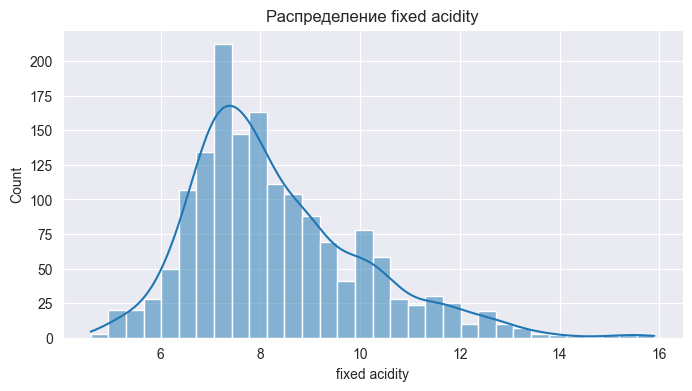

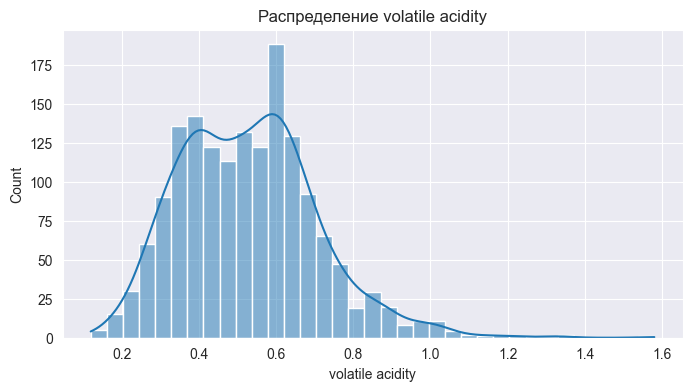

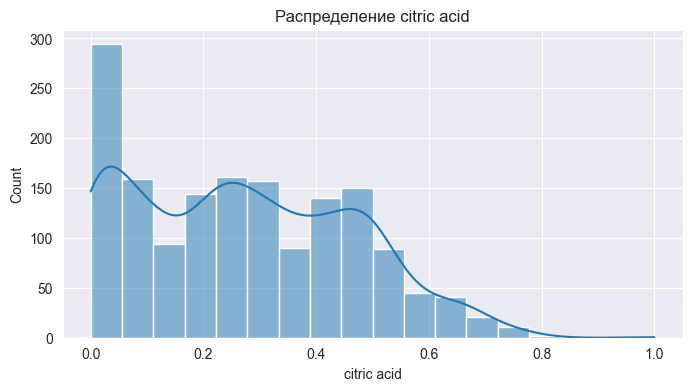

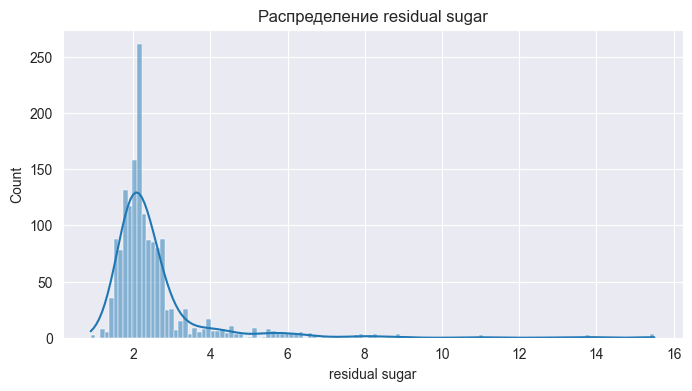

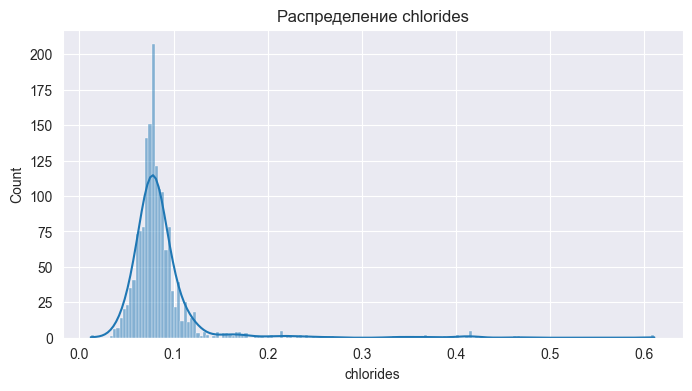

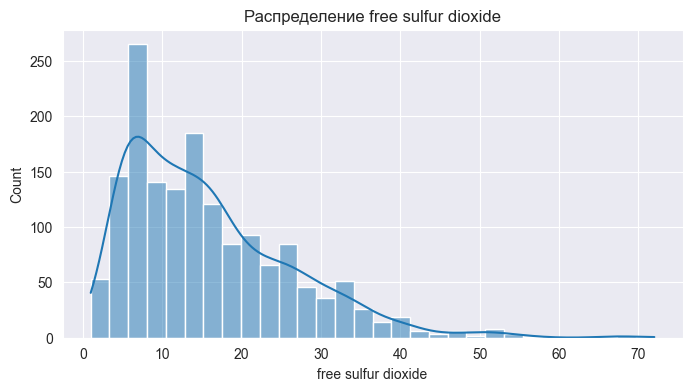

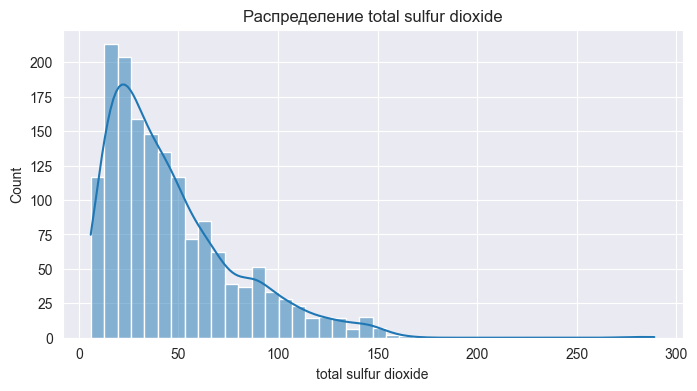

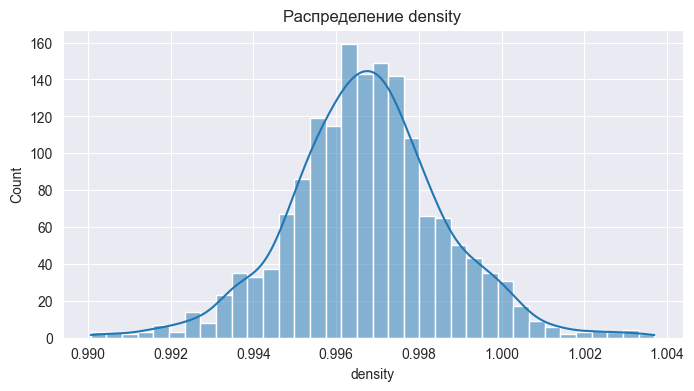

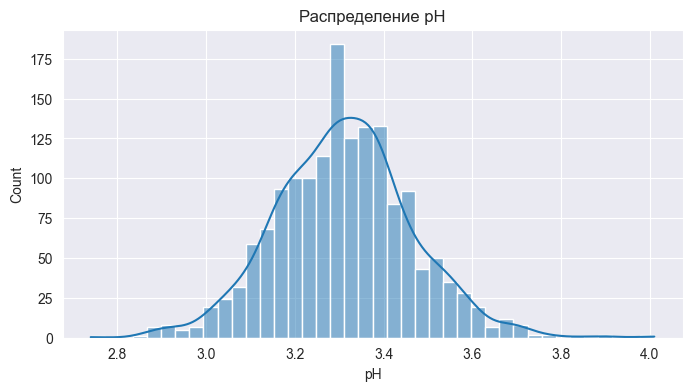

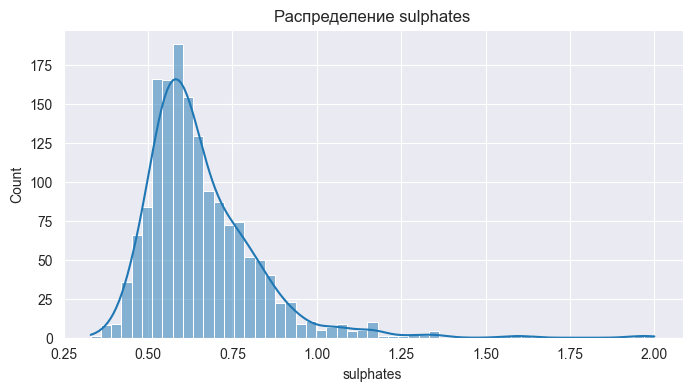

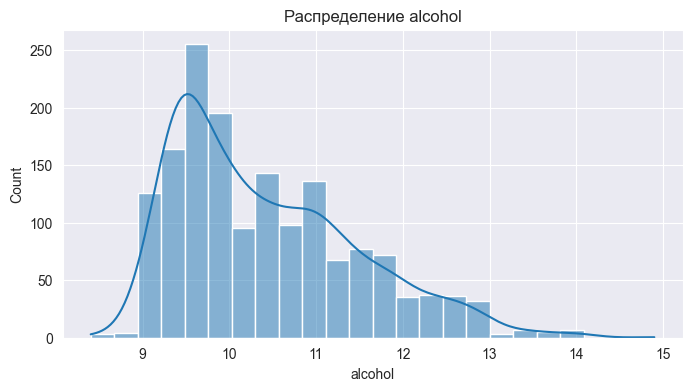

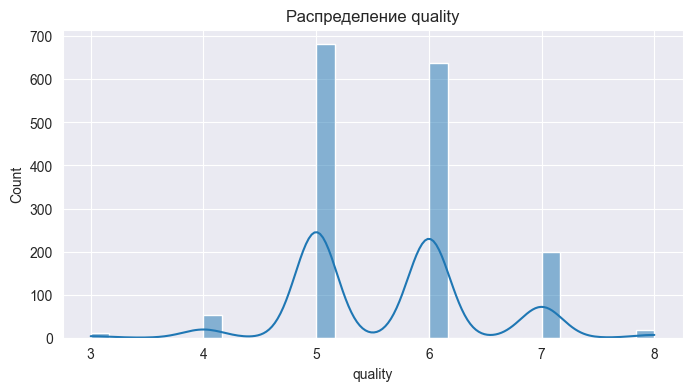

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

for column in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Распределение {column}')
    plt.show()


Видим выбросы, убираем их методами показанными на практике.

In [38]:
columns = [col for col in df.columns if col != 'quality']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Столбец: {col}")
    print(f"Q1 (25-й перцентиль): {Q1}")
    print(f"Q3 (75-й перцентиль): {Q3}")
    print(f"IQR: {IQR}")
    print(f"Нижняя граница: {lower_bound}")
    print(f"Верхняя граница: {upper_bound}")
    print(f"Количество выбросов по методу IQR: {len(outliers_iqr)}\n")

Столбец: fixed acidity
Q1 (25-й перцентиль): 7.1
Q3 (75-й перцентиль): 9.2
IQR: 2.0999999999999996
Нижняя граница: 3.95
Верхняя граница: 12.349999999999998
Количество выбросов по методу IQR: 49

Столбец: volatile acidity
Q1 (25-й перцентиль): 0.39
Q3 (75-й перцентиль): 0.64
IQR: 0.25
Нижняя граница: 0.015000000000000013
Верхняя граница: 1.0150000000000001
Количество выбросов по методу IQR: 19

Столбец: citric acid
Q1 (25-й перцентиль): 0.09
Q3 (75-й перцентиль): 0.42
IQR: 0.32999999999999996
Нижняя граница: -0.4049999999999999
Верхняя граница: 0.9149999999999999
Количество выбросов по методу IQR: 1

Столбец: residual sugar
Q1 (25-й перцентиль): 1.9
Q3 (75-й перцентиль): 2.6
IQR: 0.7000000000000002
Нижняя граница: 0.8499999999999996
Верхняя граница: 3.6500000000000004
Количество выбросов по методу IQR: 155

Столбец: chlorides
Q1 (25-й перцентиль): 0.07
Q3 (75-й перцентиль): 0.09
IQR: 0.01999999999999999
Нижняя граница: 0.04000000000000002
Верхняя граница: 0.11999999999999998
Количество 

In [39]:
from scipy.stats import stats
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

outliers_per_column = {}

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = df[z_scores > Z_THRESHOLD]
    outliers_per_column[col] = outliers[[col]].copy()
    outliers_per_column[col]['Z_Score'] = z_scores[z_scores > Z_THRESHOLD]

    print(f"Столбец: {col}")
    print(f"Количество выбросов: {len(outliers)}")
    print(outliers_per_column[col])
    print("\n")

Столбец: fixed acidity
Количество выбросов: 12
     fixed acidity   Z_Score
243           15.0  3.838072
244           15.0  3.838072
347           13.8  3.148635
374           14.0  3.263541
381           13.7  3.091182
391           13.7  3.091182
442           15.6  4.182790
544           14.3  3.435900
554           15.5  4.125337
555           15.5  4.125337
557           15.6  4.182790
652           15.9  4.355149


Столбец: volatile acidity
Количество выбросов: 10
      volatile acidity   Z_Score
38               1.130  3.364062
120              1.070  3.028873
126              1.330  4.481357
127              1.330  4.481357
199              1.090  3.140603
672              1.240  3.978574
690              1.185  3.671318
724              1.115  3.280264
1299             1.580  5.877976
1312             1.180  3.643385


Столбец: citric acid
Количество выбросов: 1
     citric acid   Z_Score
151          1.0  3.743574


Столбец: residual sugar
Количество выбросов: 30
      resid

C:\Users\Igor\AppData\Local\Temp\ipykernel_2316\4114398216.py:9: DeprecationWarning: Please import `zscore` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  z_scores = np.abs(stats.zscore(df[col]))
C:\Users\Igor\AppData\Local\Temp\ipykernel_2316\4114398216.py:9: DeprecationWarning: Please import `zscore` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  z_scores = np.abs(stats.zscore(df[col]))
C:\Users\Igor\AppData\Local\Temp\ipykernel_2316\4114398216.py:9: DeprecationWarning: Please import `zscore` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  z_scores = np.abs(stats.zscore(df[col]))
C:\Users\Igor\AppData\Local\Temp\ipykernel_2316\4114398216.py:9: DeprecationWarning: Please import `zscore` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and

Далее заменим выбросы по принципу показанному на практике. Посмотрим на ящиках с усами результат.

In [40]:
df_cleaned = df.copy()

Столбец: fixed acidity
Нижняя граница: 3.95
Верхняя граница: 12.349999999999998
Количество замененных выбросов: 49
     fixed acidity  fixed acidity_processed
205           12.8                    12.35
206           12.8                    12.35
243           15.0                    12.35
244           15.0                    12.35
264           12.5                    12.35
=== Статистика до обработки ===
count    1599.000000
mean        8.319637
std         1.741096
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        8.290901
std         1.655860
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        12.350000
Name: fixed acidity_processed, dtype: float64


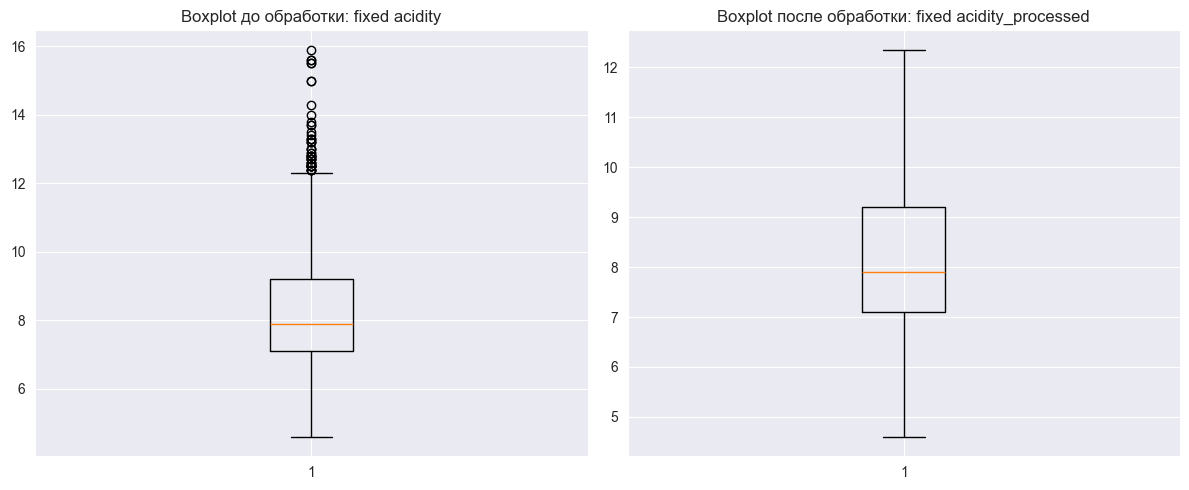

Столбец: volatile acidity
Нижняя граница: 0.015000000000000013
Верхняя граница: 1.0150000000000001
Количество замененных выбросов: 19
     volatile acidity  volatile acidity_processed
38               1.13                       1.015
94               1.02                       1.015
120              1.07                       1.015
126              1.33                       1.015
127              1.33                       1.015
=== Статистика до обработки ===
count    1599.000000
mean        0.527821
std         0.179060
min         0.120000
25%         0.390000
50%         0.520000
75%         0.640000
max         1.580000
Name: volatile acidity, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        0.526429
std         0.174045
min         0.120000
25%         0.390000
50%         0.520000
75%         0.640000
max         1.015000
Name: volatile acidity_processed, dtype: float64


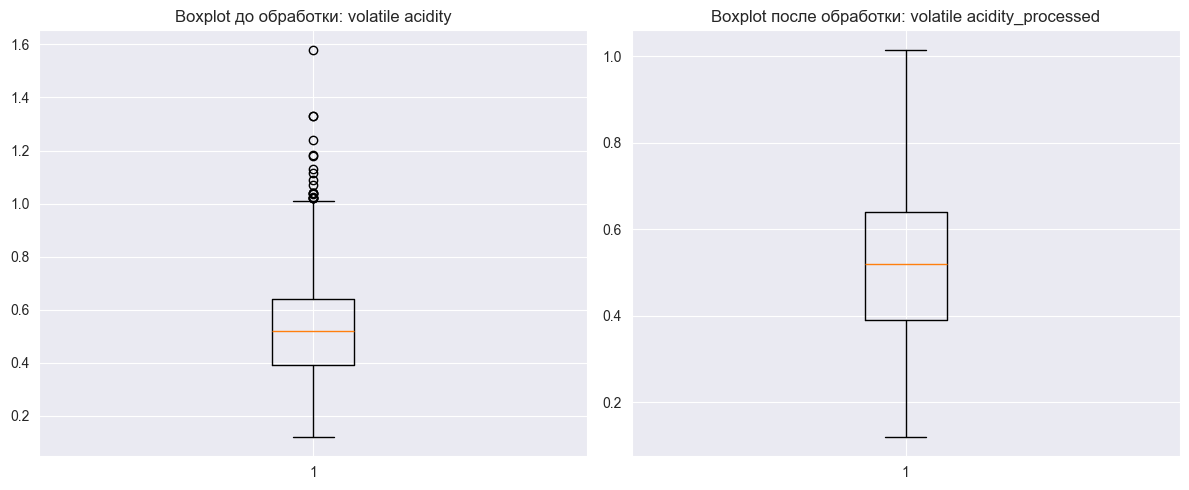

Столбец: citric acid
Нижняя граница: -0.4049999999999999
Верхняя граница: 0.9149999999999999
Количество замененных выбросов: 1
     citric acid  citric acid_processed
151          1.0                  0.915
=== Статистика до обработки ===
count    1599.000000
mean        0.270976
std         0.194801
min         0.000000
25%         0.090000
50%         0.260000
75%         0.420000
max         1.000000
Name: citric acid, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        0.270922
std         0.194614
min         0.000000
25%         0.090000
50%         0.260000
75%         0.420000
max         0.915000
Name: citric acid_processed, dtype: float64


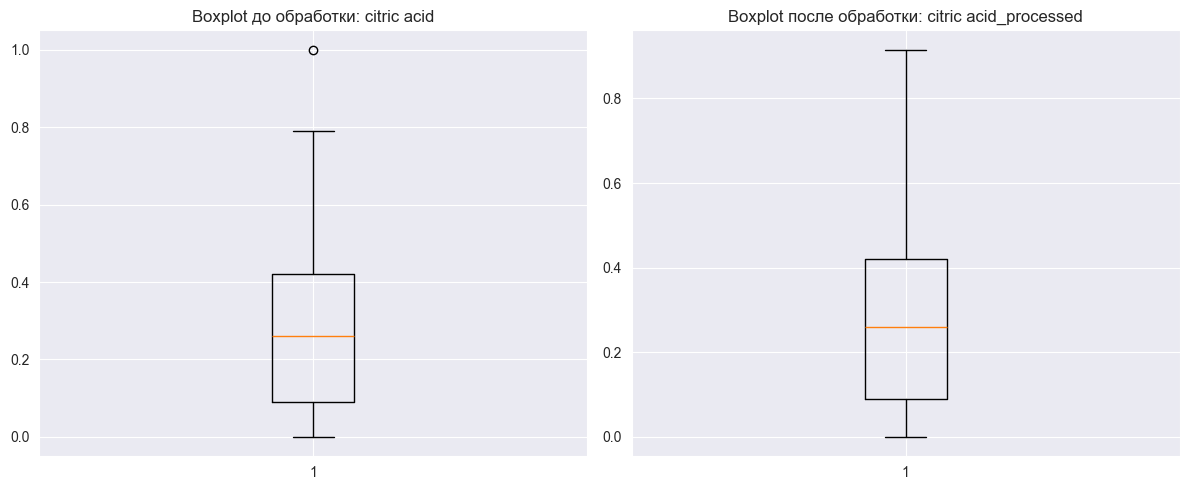

Столбец: residual sugar
Нижняя граница: 0.8499999999999996
Верхняя граница: 3.6500000000000004
Количество замененных выбросов: 155
    residual sugar  residual sugar_processed
9              6.1                      3.65
11             6.1                      3.65
14             3.8                      3.65
15             3.9                      3.65
18             4.4                      3.65
=== Статистика до обработки ===
count    1599.000000
mean        2.538806
std         1.409928
min         0.900000
25%         1.900000
50%         2.200000
75%         2.600000
max        15.500000
Name: residual sugar, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        2.322358
std         0.609493
min         0.900000
25%         1.900000
50%         2.200000
75%         2.600000
max         3.650000
Name: residual sugar_processed, dtype: float64


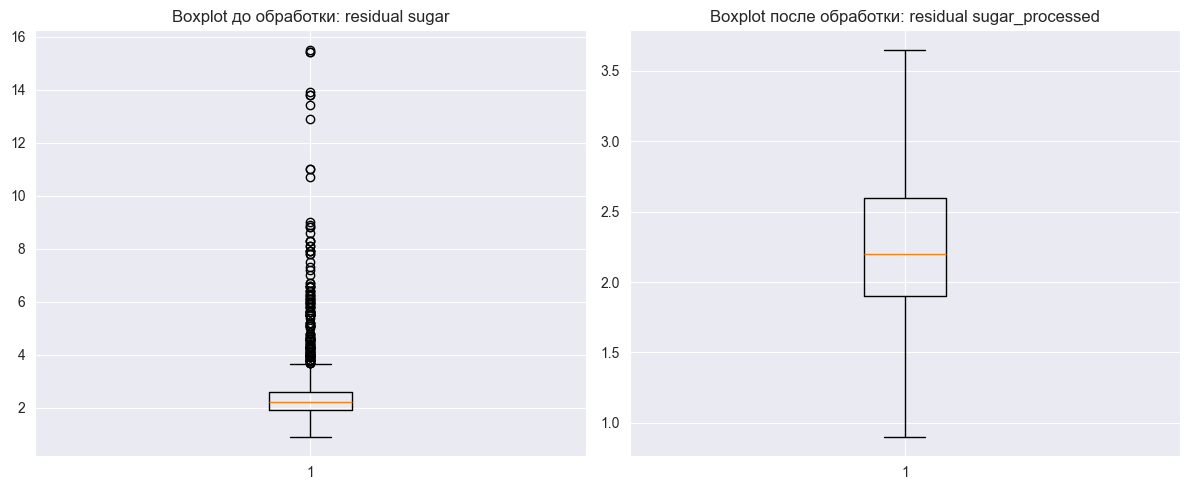

Столбец: chlorides
Нижняя граница: 0.04000000000000002
Верхняя граница: 0.11999999999999998
Количество замененных выбросов: 112
    chlorides  chlorides_processed
14      0.176                 0.12
15      0.170                 0.12
17      0.368                 0.12
19      0.341                 0.12
38      0.172                 0.12
=== Статистика до обработки ===
count    1599.000000
mean        0.087467
std         0.047065
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        0.081194
std         0.017822
min         0.040000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.120000
Name: chlorides_processed, dtype: float64


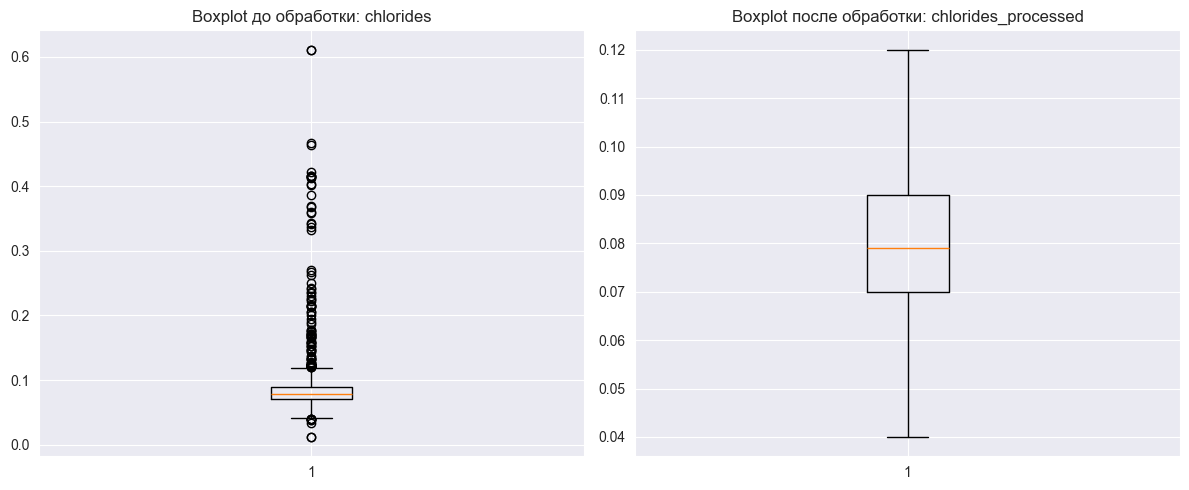

Столбец: free sulfur dioxide
Нижняя граница: -14.0
Верхняя граница: 42.0
Количество замененных выбросов: 30
     free sulfur dioxide  free sulfur dioxide_processed
14                  52.0                           42.0
15                  51.0                           42.0
57                  50.0                           42.0
396                 68.0                           42.0
400                 68.0                           42.0
=== Статистика до обработки ===
count    1599.000000
mean       15.874922
std        10.460157
min         1.000000
25%         7.000000
50%        14.000000
75%        21.000000
max        72.000000
Name: free sulfur dioxide, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean       15.689181
std         9.837494
min         1.000000
25%         7.000000
50%        14.000000
75%        21.000000
max        42.000000
Name: free sulfur dioxide_processed, dtype: float64


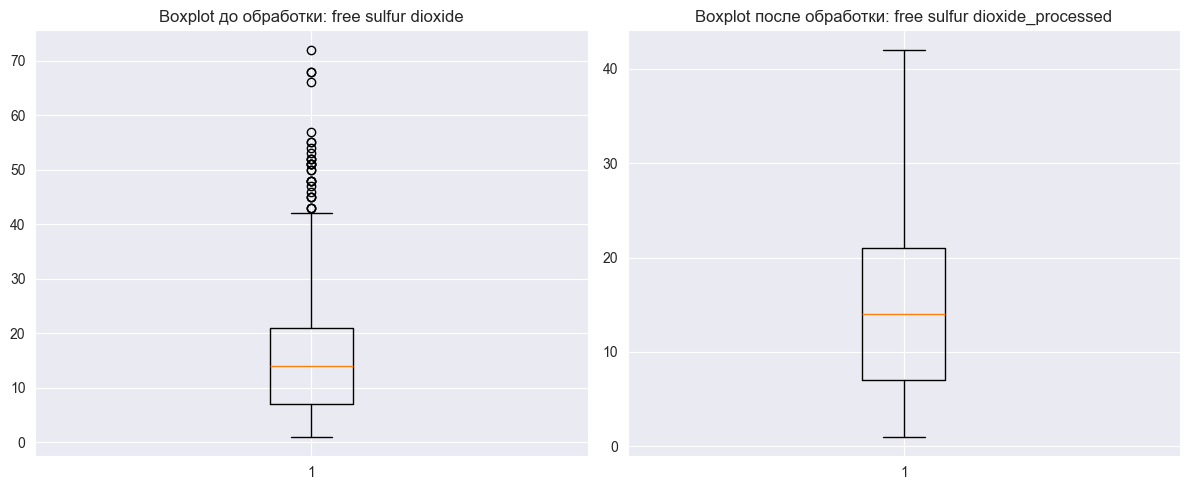

Столбец: total sulfur dioxide
Нижняя граница: -38.0
Верхняя граница: 122.0
Количество замененных выбросов: 55
    total sulfur dioxide  total sulfur dioxide_processed
14                 145.0                           122.0
15                 148.0                           122.0
86                 136.0                           122.0
88                 125.0                           122.0
90                 140.0                           122.0
=== Статистика до обработки ===
count    1599.000000
mean       46.467792
std        32.895324
min         6.000000
25%        22.000000
50%        38.000000
75%        62.000000
max       289.000000
Name: total sulfur dioxide, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean       45.714822
std        30.374029
min         6.000000
25%        22.000000
50%        38.000000
75%        62.000000
max       122.000000
Name: total sulfur dioxide_processed, dtype: float64


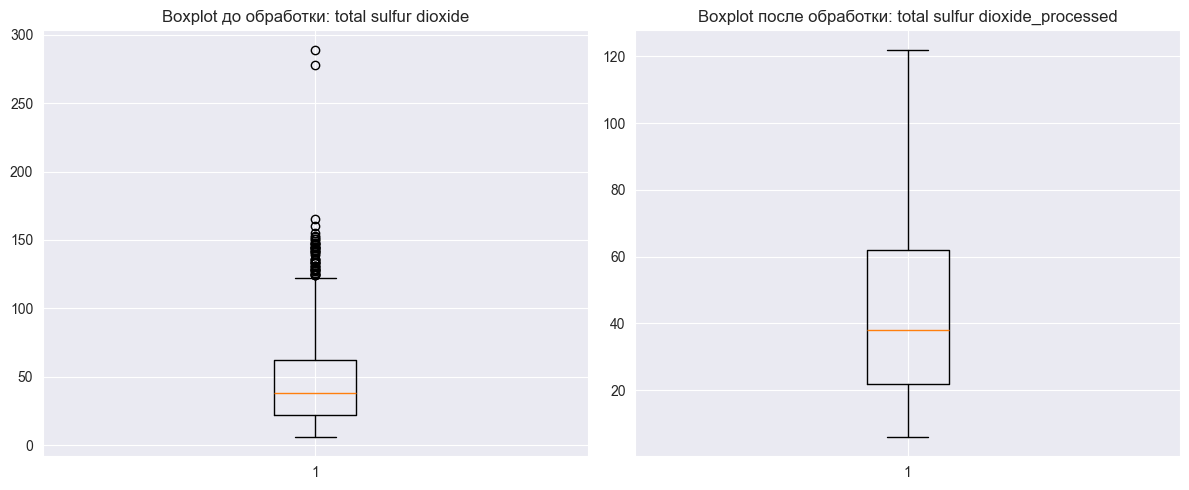

Столбец: density
Нижняя граница: 0.9922475000000001
Верхняя граница: 1.0011875
Количество замененных выбросов: 45
     density  density_processed
142   0.9916           0.992248
144   0.9916           0.992248
294   1.0014           1.001187
324   1.0015           1.001187
325   1.0015           1.001187
=== Статистика до обработки ===
count    1599.000000
mean        0.996747
std         0.001887
min         0.990070
25%         0.995600
50%         0.996750
75%         0.997835
max         1.003690
Name: density, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        0.996742
std         0.001806
min         0.992248
25%         0.995600
50%         0.996750
75%         0.997835
max         1.001187
Name: density_processed, dtype: float64


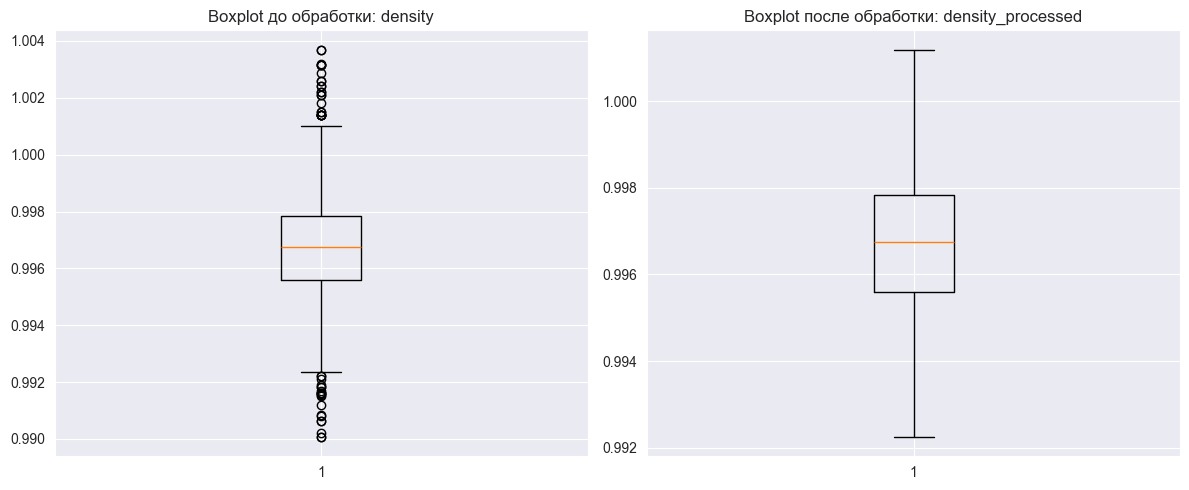

Столбец: pH
Нижняя граница: 2.925
Верхняя граница: 3.6849999999999996
Количество замененных выбросов: 35
       pH  pH_processed
45   3.90         3.685
94   3.75         3.685
95   3.85         3.685
151  2.74         2.925
268  3.69         3.685
=== Статистика до обработки ===
count    1599.000000
mean        3.311113
std         0.154386
min         2.740000
25%         3.210000
50%         3.310000
75%         3.400000
max         4.010000
Name: pH, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        3.310353
std         0.149851
min         2.925000
25%         3.210000
50%         3.310000
75%         3.400000
max         3.685000
Name: pH_processed, dtype: float64


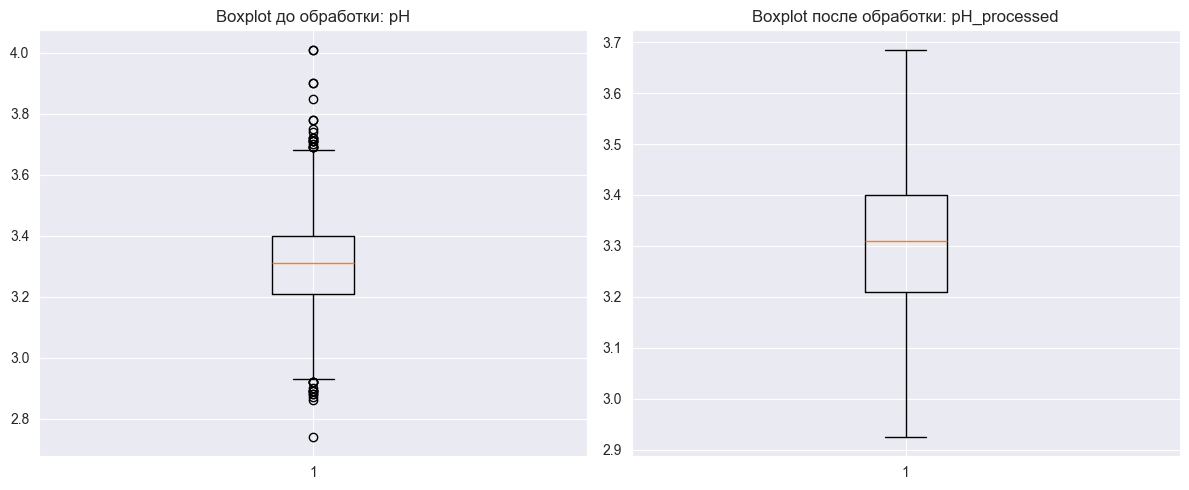

Столбец: sulphates
Нижняя граница: 0.28000000000000014
Верхняя граница: 0.9999999999999999
Количество замененных выбросов: 59
    sulphates  sulphates_processed
13       1.56                  1.0
17       1.28                  1.0
19       1.08                  1.0
43       1.20                  1.0
79       1.12                  1.0
=== Статистика до обработки ===
count    1599.000000
mean        0.658149
std         0.169507
min         0.330000
25%         0.550000
50%         0.620000
75%         0.730000
max         2.000000
Name: sulphates, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        0.649831
std         0.137086
min         0.330000
25%         0.550000
50%         0.620000
75%         0.730000
max         1.000000
Name: sulphates_processed, dtype: float64


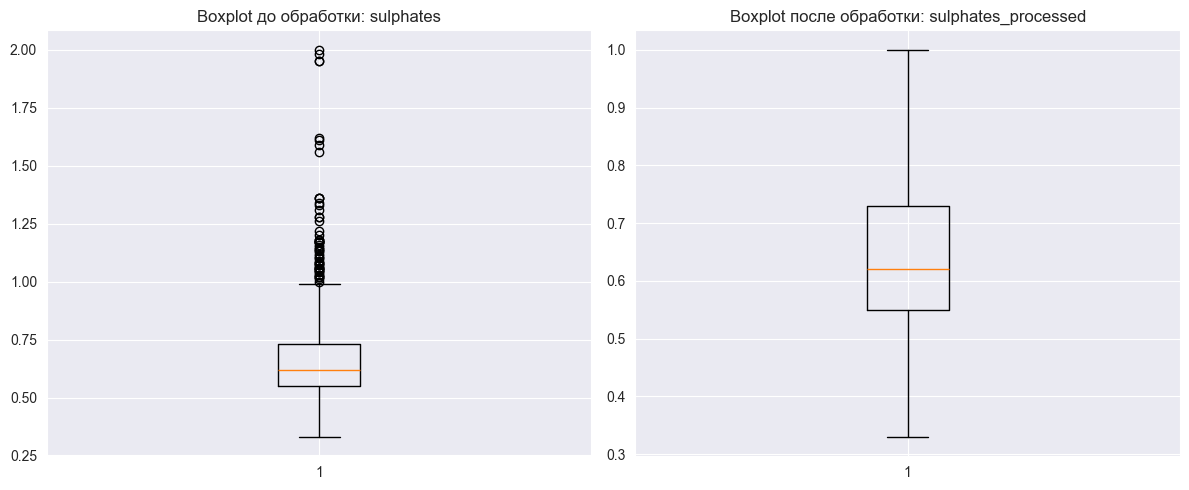

Столбец: alcohol
Нижняя граница: 7.1000000000000005
Верхняя граница: 13.5
Количество замененных выбросов: 13
     alcohol  alcohol_processed
142     14.0               13.5
144     14.0               13.5
467     14.0               13.5
588     14.0               13.5
652     14.9               13.5
=== Статистика до обработки ===
count    1599.000000
mean       10.422983
std         1.065668
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean       10.419627
std         1.054808
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        13.500000
Name: alcohol_processed, dtype: float64


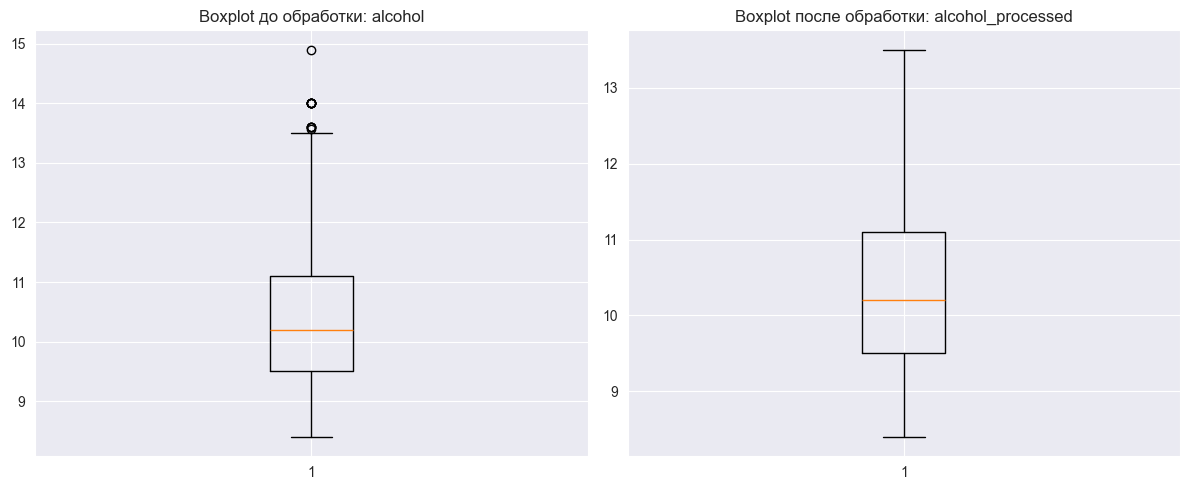

C:\Users\Igor\AppData\Local\Temp\ipykernel_2316\3690635408.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cleaned.loc[df_cleaned[column] > upper_bound, processed_col_name] = upper_bound


Столбец: quality
Нижняя граница: 3.5
Верхняя граница: 7.5
Количество замененных выбросов: 28
     quality  quality_processed
267        8                7.5
278        8                7.5
390        8                7.5
440        8                7.5
455        8                7.5
=== Статистика до обработки ===
count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64
=== Статистика после обработки ===
count    1599.000000
mean        5.633521
std         0.783211
min         3.500000
25%         5.000000
50%         6.000000
75%         6.000000
max         7.500000
Name: quality_processed, dtype: float64


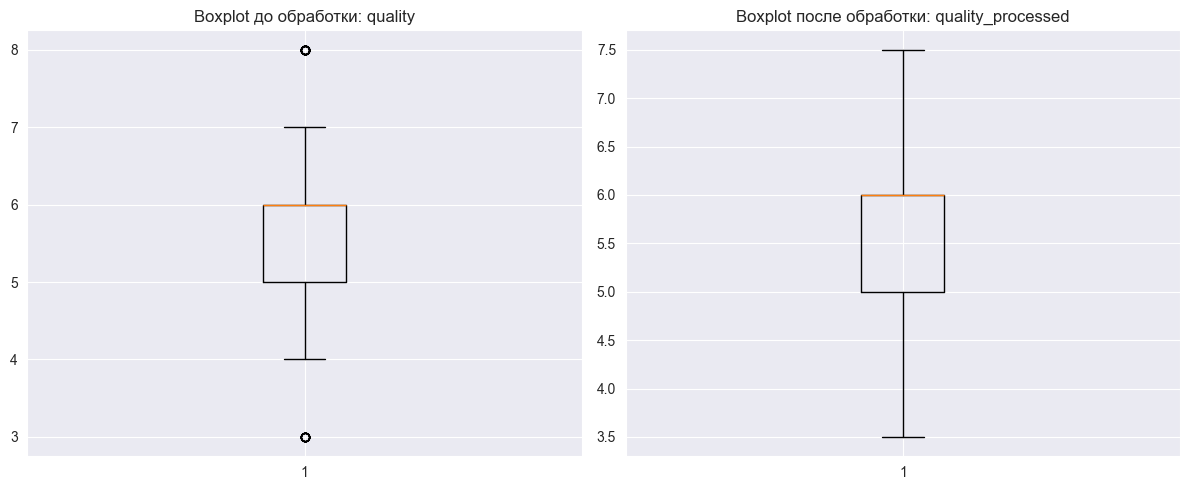

In [41]:
numeric_cols = df_cleaned.select_dtypes(include='number').columns

for column in numeric_cols:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    processed_col_name = column + '_processed'
    df_cleaned[processed_col_name] = df_cleaned[column]
    df_cleaned.loc[df_cleaned[column] > upper_bound, processed_col_name] = upper_bound
    df_cleaned.loc[df_cleaned[column] < lower_bound, processed_col_name] = lower_bound

    outliers_replaced = df_cleaned[df_cleaned[column] != df_cleaned[processed_col_name]]
    print(f"Столбец: {column}")
    print(f"Нижняя граница: {lower_bound}")
    print(f"Верхняя граница: {upper_bound}")
    print(f"Количество замененных выбросов: {len(outliers_replaced)}")
    print(outliers_replaced[[column, processed_col_name]].head())
    print("=== Статистика до обработки ===")
    print(df_cleaned[column].describe())
    print("=== Статистика после обработки ===")
    print(df_cleaned[processed_col_name].describe())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.boxplot(df_cleaned[column].dropna())
    ax1.set_title(f'Boxplot до обработки: {column}')
    ax2.boxplot(df_cleaned[processed_col_name].dropna())
    ax2.set_title(f'Boxplot после обработки: {processed_col_name}')
    plt.tight_layout()
    plt.show()

Далее делаем heatmap, чтобы посмотреть корреляцию признаков.

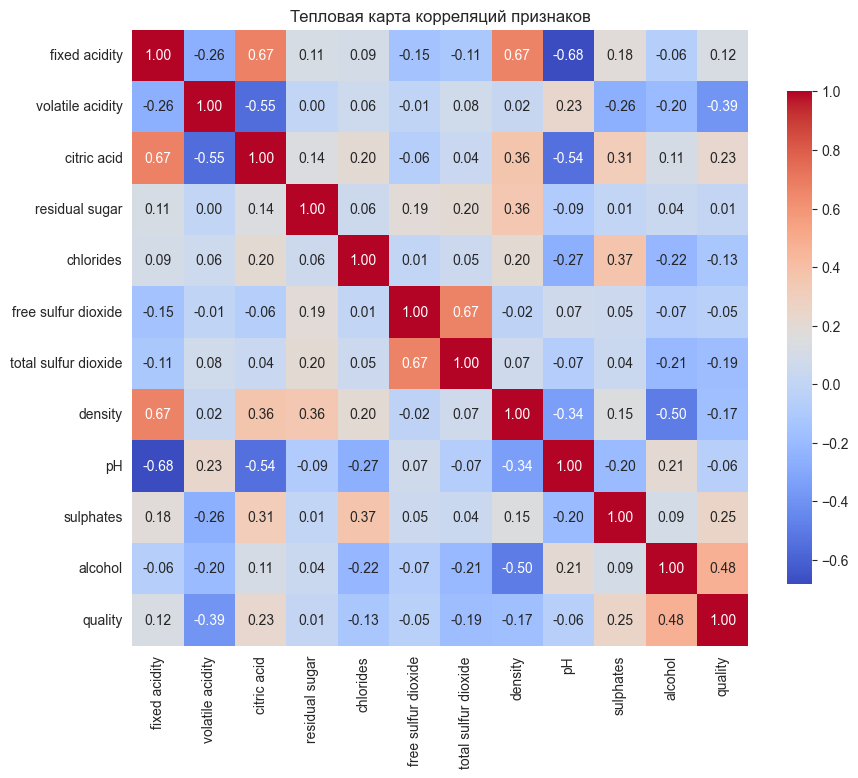

In [42]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Тепловая карта корреляций признаков')
plt.show()

Выбираем переменную quality как зависимую.

In [43]:
X = df.drop(columns=['quality'])
y = df['quality']

Далее применяем метод главных компонентов, перед этим обработаем переменные и выберем лучшие.

Объяснённая дисперсия для первых 2 компонентов: 0.9949


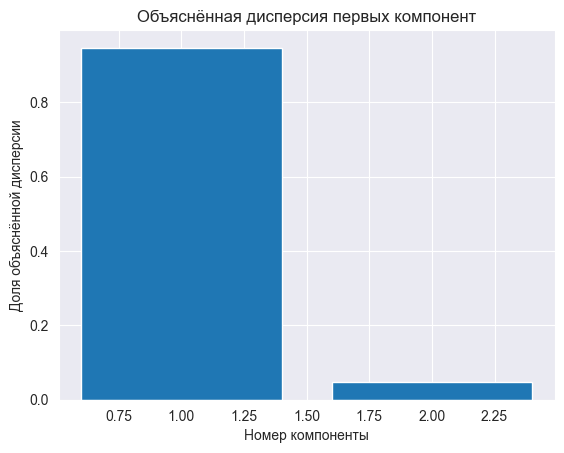

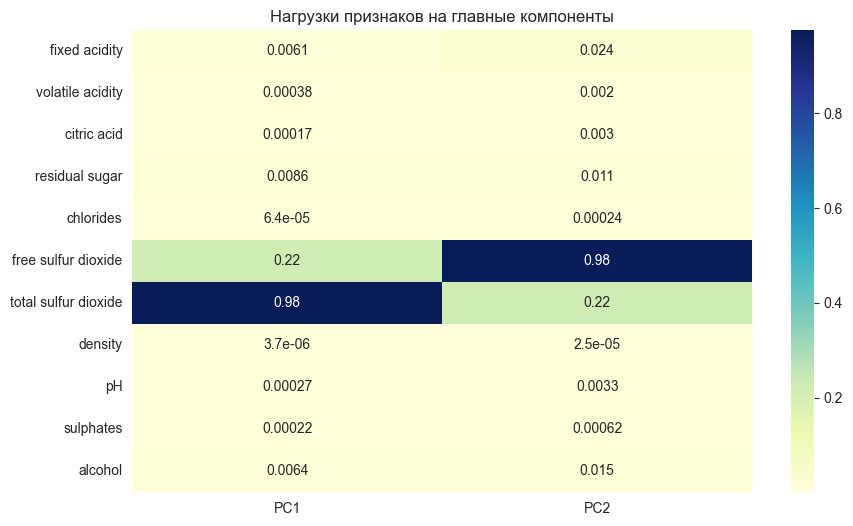

In [84]:
# Центрирование признаков
X_centered = X - np.mean(X, axis=0)

# Ковариационная матрица
cov_matrix = np.cov(X_centered, rowvar=False)

# Собственные значения и векторы
eigvals, eigvecs = np.linalg.eigh(cov_matrix)  # более стабильный вариант

# Сортируем по убыванию
sorted_idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[sorted_idx]
eigvecs = eigvecs[:, sorted_idx]

# Количество компонентов
n_components = 2
components = eigvecs[:, :n_components]

# Проекция
X_pca = X_centered.dot(components)

# Доля объяснённой дисперсии
explained_var = eigvals / eigvals.sum()
print(f"Объяснённая дисперсия для первых {n_components} компонентов: {explained_var[:n_components].sum():.4f}")

# Визуализация объясненной дисперсии
plt.bar(range(1, n_components+1), explained_var[:n_components])
plt.xlabel('Номер компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Объяснённая дисперсия первых компонент')
plt.show()

# Визуализация нагрузок признаков (loadings)
loadings = pd.DataFrame(components, index=X.columns, columns=[f'PC{i+1}' for i in range(n_components)])
plt.figure(figsize=(10, 6))
sns.heatmap(np.abs(loadings), annot=True, cmap='YlGnBu')
plt.title('Нагрузки признаков на главные компоненты')
plt.show()